# 1.文本对话(chat completions接口)

## 1.1 大模型api接口概况

尽管不同厂商（OpenAI、Anthropic、百度千帆、阿里百炼等）以及各API聚合商(合商openrouter等)的接口细节不同，但**几乎所有大模型 API 都遵循类似的结构**：

| 要素 | 说明 |
|---|---|
| 请求方法 | 几乎全部是 `POST` |
| Content-Type | `application/json` |
| 认证方式 | 请求头中携带 API Key，通常形如 `Authorization: Bearer {your_api_key}` |
| 请求体核心字段 | `model`（用哪个模型）、`messages`（对话内容）、其他生成参数 |
| 响应核心字段 | 生成的文本内容、token 用量统计、结束原因等 |

这种相似性是因为很多厂商的接口设计都参考了 OpenAI 最早提出的 **Chat Completions** 接口规范，所以即使换了厂商，调用逻辑也大同小异——这也是为什么学会一家的调用方式，迁移到另一家通常只需改 `url`、`headers` 和少量参数名。


参考：
- deepseek：https://api-docs.deepseek.com/
- 千帆：https://cloud.baidu.com/doc/qianfan-api/s/3m7of64lb
- 百炼：https://bailian.console.aliyun.com/cn-beijing?tab=api#/api/?type=model&url=3016807
- openai: https://developers.openai.com/api/docs/guides/text?lang=python
- anthropic: https://platform.claude.com/docs/en/get-started#curl
- openrouter: https://openrouter.ai/docs/quickstart#using-the-client-sdks

## 1.2 典型请求结构

**Chat Completions** 接口请求
```html
POST /v1/chat/completions HTTP/1.1
Host: api.provider.com
Content-Type: application/json
Authorization: Bearer {your_api_key}

{
"model": "模型名称",
"messages": [
{"role": "system", "content": "你是一个有帮助的助手"},
{"role": "user", "content": "你好，介绍一下你自己"}
],
"temperature": 0.7,
"max_tokens": 500,
"stream": false
}
```

**核心字段说明：**

- `model`：指定调用哪个模型版本，不同厂商命名方式不同
- `messages`：对话历史，是一个列表，每条消息包含：
  - `role`：消息角色，常见有 `system`（系统设定/人设）、`user`（用户输入）、`assistant`（模型之前的回复，多轮对话时需要带上）
  - `content`：具体内容
- `temperature`：控制生成结果的随机性，取值通常在 0~1 或 0~2 之间，越高越"有创造性"，越低越"稳定保守"
- `max_tokens`：限制本次生成的最大 token 数量（避免无限生成、控制成本）
- `stream`：是否启用流式返回，`true` 则边生成边返回（类似打字机效果），`false` 则等全部生成完毕后一次性返回

## 1.3 典型响应结构

**Chat Completions** 接口响应

```json
{
    "id": "chatcmpl-xxxx",
    "model": "模型名称",
    "choices": [
        {
            "index": 0,
            "message": {
                "role": "assistant",
                "content": "你好！我是一个AI助手，可以帮你..."
            },
            "finish_reason": "stop"
        }
    ],
    "usage": {
        "prompt_tokens": 20,
        "completion_tokens": 35,
        "total_tokens": 55
    }
}
```

**核心字段说明：**

- `choices`：生成结果列表（部分接口支持一次生成多个候选回复）
  - `message.content`：模型真正生成的文本内容，这是我们最关心的部分
  - `finish_reason`：生成结束的原因，常见值：
    - `stop`：正常生成完毕
    - `length`：因达到 `max_tokens` 限制被截断
    - `content_filter`：内容被安全审核拦截
- `usage`：本次调用消耗的 token 数量，通常按这个计费
  - `prompt_tokens`：输入部分消耗的 token 数
  - `completion_tokens`：输出部分消耗的 token 数
  - `total_tokens`：两者之和

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.environ.get("QIANFAN_API_KEY")

In [2]:
import requests
import json
url="https://qianfan.baidubce.com/v2/chat/completions"
headers={
    'Content-Type': 'application/json',
    'Authorization': f'Bearer {api_key}'
}

payload = json.dumps({
        "model": "deepseek-v4-flash",
        "messages": [
            {
                "role": "system",
                "content": "You are a helpful assistant."
            },
            {
                "role": "user",
                "content": "你好"
            }
        ]
    })
response=requests.post(url,headers=headers,data=payload)
response.json()

{'id': 'as-98ci2t8s2n',
 'object': 'chat.completion',
 'created': 1782271017,
 'model': 'deepseek-v4-flash',
 'choices': [{'index': 0,
   'message': {'role': 'assistant',
    'content': '你好！很高兴见到你。😊 今天有什么可以帮你的吗？或者我们可以随便聊聊～',
    'reasoning_content': '嗯，用户发来一个简单的问候“你好”，这是一个非常基础的社交开场。我需要用同样友好热情的语气回应，让用户感受到温暖和欢迎。可以主动表达问候，并开启话题邀请用户继续交流。想到了用“很高兴见到你”来表达积极态度，再用一个开放式的提问“今天有什么可以帮你的吗？”来引导对话继续。这样既完成了礼节性回应，又为后续互动创造了机会。'},
   'finish_reason': 'stop',
   'flag': 0}],
 'usage': {'prompt_tokens': 11,
  'completion_tokens': 111,
  'total_tokens': 122,
  'completion_tokens_details': {'reasoning_tokens': 88}}}

In [3]:
#只取出回答部分
print(response.json()['choices'][0]['message']['content'])

你好！很高兴见到你。😊 今天有什么可以帮你的吗？或者我们可以随便聊聊～


## 1.4 多轮对话

通过chat completion接口实现多轮对话，只需要对messages列表进行管理

In [24]:
##实现多轮对话
import requests,json
url="https://qianfan.baidubce.com/v2/chat/completions"
headers={
    'Content-Type': 'application/json',
    'Authorization': f'Bearer {api_key}'
}

print('输入/exit退出对话模式')
prompt=input('user:')
messages=[{'role':'system','content':'you are a helpful assistant'}]
while prompt!='/exit':
    messages.append({'role':'user','content':prompt})
    
    payload = json.dumps({
        "model": "deepseek-v4-flash",
        "messages": messages})
    
    response=requests.post(url,headers=headers,data=payload)
    content=response.json()['choices'][0]['message']['content']
    print(f'assistant:{content}')

    #管理messages
    messages.append(response.json()["choices"][0]["message"])
    
    prompt=input()

输入/exit退出对话模式


user: hello


assistant:Hello! How can I help you today?


 1+1=?


assistant:1 + 1 = 2



KeyboardInterrupt



## 1.5 流式对话

设置两个 `stream` 参数为 `True` 后，接口将遵循 **SSE（Server-Sent Events，服务器推送事件）** 协议，分段返回内容。

### 特点
**1. 响应头标识**
```html
   Content-Type: text/event-stream
   Cache-Control: no-cache
   Connection: keep-alive
```
**2. 数据格式规范**

每条消息以 `data: ` 开头，以两个换行符（`\n\n`）作为消息结束的分隔符。返回的是字节流，需要decode

**深度思考时返回示例：**

```json
data: {"id":"as-0xyy2ufa8w","object":"chat.completion.chunk","created":1782114481,"model":"deepseek-v4-flash","choices":[{"index":0,"delta":{"content":null,"role":"assistant","reasoning_content":"我们"},"flag":0}]}
```

**正文返回示例：**

```json
data: {"id":"as-0xyy2ufa8w","object":"chat.completion.chunk","created":1782114481,"model":"deepseek-v4-flash","choices":[{"index":0,"delta":{"content":"发展始于"},"flag":0}]}
```

**结束示例：**

```json
data: [DONE]
```


注意:由于jupyter 前端渲染节流问题(高速print的频率超过浏览器渲染速度，导致丢失中间帧)，直接使用print打印流式输出会缺字,以下代码已给出解决方法。

In [5]:
import requests
import json
from IPython.display import Pretty,Markdown,display, update_display
url="https://qianfan.baidubce.com/v2/chat/completions"
headers={
    'Content-Type': 'application/json',
    'Authorization': f'Bearer {api_key}'
}

payload = json.dumps({
        "model": "deepseek-v4-flash",
        "messages": [
            {
                "role": "system",
                "content": "You are a helpful assistant."
            },
            {
                "role": "user",
                "content": "介绍一下人工智能发展概况"
            }
        ],
        "stream":True  #关键：开启流式输出
        
    })
response=requests.post(url,headers=headers,data=payload,stream=True) #post请求也要设置stream=True
is_reasoning=False #在切换时打印【深度思考】或【正文】

# 创建一个独立的占位符，用于流式更新
display("", display_id="stream_output")

full_text = ""
for line in response.iter_lines():
    if not line:
        continue
        
    line=line.decode('UTF-8') #decode为字符串
    
    if line.startswith("data: "):#去掉开头的data:
        line = line[len("data: "):]
    if line.strip() == "[DONE]":  # 处理流结束标记，避免拿它去做json.loads
        break
        
    delta=json.loads(line)['choices'][0]['delta']
    reasoning = delta.get('reasoning_content')
    content = delta.get('content')
    if reasoning:
        if not is_reasoning:
            full_text+='【深度思考】:'
            is_reasoning = True
        full_text+=reasoning
    if content:
        if is_reasoning:
            full_text+='\n\n【正文】:'
            is_reasoning = False
        full_text+=content
    update_display(Markdown(full_text), display_id="stream_output")  # 只更新这个占位符，不影响其他输出。注意要加Pretty(xx)或Markdown(xxx)，display输出的是repr字符串表示
    # print(line,end='')

【深度思考】:我们根据民法典文本内容抽取5个高质量的问答对。需要聚焦具体条文、概念或规则，回答准确简洁。按照JSON格式输出。

【正文】:[
  {
    "prompt": "根据《中华人民共和国民法典》的规定，自然人的民事权利能力从何时开始到何时结束？",
    "response": "自然人从出生时起到死亡时止，具有民事权利能力。"
  },
  {
    "prompt": "《中华人民共和国民法典》中，限制民事行为能力人的年龄界定是多少岁？",
    "response": "六周岁以上的未成年人为限制民事行为能力人。"
  },
  {
    "prompt": "哪些情形下，人民法院可以根据申请撤销监护人的资格？",
    "response": "实施严重损害被监护人身心健康行为；怠于履行监护职责导致被监护人处于危困状态；有严重侵害被监护人合法权益的其他行为。"
  },
  {
    "prompt": "根据民法典，法人终止的原因有哪些？",
    "response": "法人解散、法人被宣告破产、法律规定的其他原因。"
  },
  {
    "prompt": "民法典规定的一般诉讼时效期间是多长时间？",
    "response": "向人民法院请求保护民事权利的诉讼时效期间为三年。"
  }
]

## 1.6 练习

练习1：尝试流式多轮对话
##### 答案

In [7]:
import requests,json
from IPython.display import Pretty,Markdown,display, update_display
url="https://qianfan.baidubce.com/v2/chat/completions"
headers={
    'Content-Type': 'application/json',
    'Authorization': f'Bearer {api_key}'
}
def stream_output(response):
    """打印流式输出内容"""
    # 创建一个独立的占位符，用于流式更新
    display("", display_id="stream_output")
    
    is_reasoning=False #在切换时打印【深度思考】或【正文】
    full_text = ""
    full_content=""
    for line in response.iter_lines():
        if not line:
            continue
            
        line=line.decode('UTF-8') #decode为字符串
        
        if line.startswith("data: "):#去掉开头的data:
            line = line[len("data: "):]
        if line.strip() == "[DONE]":  # 处理流结束标记，避免拿它去做json.loads
            break
            
        delta=json.loads(line)['choices'][0]['delta']
        reasoning = delta.get('reasoning_content')
        content = delta.get('content')
        if reasoning:
            if not is_reasoning:
                full_text+='【深度思考】:'
                is_reasoning = True
            full_text+=reasoning
        if content:
            if is_reasoning:
                full_text+='\n\n【正文】:'
                is_reasoning = False
            full_text+=content
            full_content+=content
        update_display(Markdown(full_text), display_id="stream_output")
    return full_content

print('输入/exit退出对话模式')
prompt=input('user:')
messages=[{'role':'system','content':'you are a helpful assistant'}]
while prompt!='/exit':
    messages.append({'role':'user','content':prompt})
    
    payload = json.dumps({
        "model": "deepseek-v4-flash",
        "messages": messages,
        "stream":True
    })
    
    response=requests.post(url,headers=headers,data=payload,stream=True)
    print(f'assistant:')
    content=stream_output(response)
    messages.append({'role':'assistant','content':content})
    prompt=input()

输入/exit退出对话模式


user: 介绍人工智能产业发展概况


assistant:


【深度思考】:我们根据民法典文本内容抽取5个高质量的问答对。需要聚焦具体条文、概念或规则，回答准确简洁。按照JSON格式输出。

【正文】:[
  {
    "prompt": "根据《中华人民共和国民法典》的规定，自然人的民事权利能力从何时开始到何时结束？",
    "response": "自然人从出生时起到死亡时止，具有民事权利能力。"
  },
  {
    "prompt": "《中华人民共和国民法典》中，限制民事行为能力人的年龄界定是多少岁？",
    "response": "六周岁以上的未成年人为限制民事行为能力人。"
  },
  {
    "prompt": "哪些情形下，人民法院可以根据申请撤销监护人的资格？",
    "response": "实施严重损害被监护人身心健康行为；怠于履行监护职责导致被监护人处于危困状态；有严重侵害被监护人合法权益的其他行为。"
  },
  {
    "prompt": "根据民法典，法人终止的原因有哪些？",
    "response": "法人解散、法人被宣告破产、法律规定的其他原因。"
  },
  {
    "prompt": "民法典规定的一般诉讼时效期间是多长时间？",
    "response": "向人民法院请求保护民事权利的诉讼时效期间为三年。"
  }
]

 /exit


练习2：调用大模型，提取问答对

从 assets\docs\中华人民共和国民法.txt 抽取 5个问答对 并写入data.json。

问答对格式示例如下：
```python
    [{"prompt": "哪个部门是差旅费归口管理部门？", "response": "永耀集团财务资产部是差旅费归口管理部门。"},
    {"prompt": "差旅费归口管理部门主要负责哪些工作？", "response": "差旅费归口管理部门负责统一、落实省管产业单位差旅费管理要求；对差旅费原始凭证合规性、准确性、完整性进行审核；负责差旅费核算。"}]
```
##### 答案

In [8]:
#建议基于流式对话实现，方便查看是否出错

import requests
import json
from IPython.display import Pretty,Markdown,display, update_display
url="https://qianfan.baidubce.com/v2/chat/completions"
headers={
    'Content-Type': 'application/json',
    'Authorization': f'Bearer {api_key}'
}

#读取文件
with open('../assets\docs\中华人民共和国民法.txt','r',encoding='utf-8') as f:
    law_text=f.read() 

#构造prompt
prompt = f"""请根据以下《中华人民共和国民法典》的文本内容，抽取5个高质量的问答对，用于法律知识问答任务。

要求：
1. 问题(prompt)应聚焦具体的法律条文、概念或规则，避免过于宽泛
2. 回答(response)应基于原文内容，准确、简洁
3. 严格按照以下JSON格式输出，不要输出任何多余的文字、解释或代码块标记（如```json）：
[{{"prompt": "问题1", "response": "回答1"}}, {{"prompt": "问题2", "response": "回答2"}}]

法律文本内容：
{law_text}
"""

payload = json.dumps({
        "model": "deepseek-v4-flash",
        "messages": [
            {
                "role": "system",
                "content": "You are a helpful assistant."
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        "stream":True  #关键：开启流式输出
        
    })
response=requests.post(url,headers=headers,data=payload,stream=True) #post请求也要设置stream=True
is_reasoning=False #在切换时打印【深度思考】或【正文】

# 创建一个独立的占位符，用于流式更新
display("", display_id="stream_output")
full_text = ""        # 含【深度思考】/【正文】标记，用于展示
content_text = ""     # 只存正文(content)部分，用于后续JSON解析

for line in response.iter_lines():
    if not line:
        continue

    line = line.decode('UTF-8')  # decode为字符串

    if line.startswith("data: "):  # 去掉开头的data:
        line = line[len("data: "):]
    if line.strip() == "[DONE]":  # 处理流结束标记，避免拿它去做json.loads
        break

    delta = json.loads(line)['choices'][0]['delta']
    reasoning = delta.get('reasoning_content')
    content = delta.get('content')
    if reasoning:
        if not is_reasoning:
            full_text += '【深度思考】:'
            is_reasoning = True
        full_text += reasoning
    if content:
        if is_reasoning:
            full_text += '\n\n【正文】:'
            is_reasoning = False
        full_text += content
        content_text += content  # 只累加正文，深度思考部分不计入
    update_display(Markdown(full_text), display_id="stream_output")  # 只更新这个占位符，不影响其他输出

【深度思考】:我们根据民法典文本内容抽取5个高质量的问答对。需要聚焦具体条文、概念或规则，回答准确简洁。按照JSON格式输出。

【正文】:[
  {
    "prompt": "根据《中华人民共和国民法典》的规定，自然人的民事权利能力从何时开始到何时结束？",
    "response": "自然人从出生时起到死亡时止，具有民事权利能力。"
  },
  {
    "prompt": "《中华人民共和国民法典》中，限制民事行为能力人的年龄界定是多少岁？",
    "response": "六周岁以上的未成年人为限制民事行为能力人。"
  },
  {
    "prompt": "哪些情形下，人民法院可以根据申请撤销监护人的资格？",
    "response": "实施严重损害被监护人身心健康行为；怠于履行监护职责导致被监护人处于危困状态；有严重侵害被监护人合法权益的其他行为。"
  },
  {
    "prompt": "根据民法典，法人终止的原因有哪些？",
    "response": "法人解散、法人被宣告破产、法律规定的其他原因。"
  },
  {
    "prompt": "民法典规定的一般诉讼时效期间是多长时间？",
    "response": "向人民法院请求保护民事权利的诉讼时效期间为三年。"
  }
]

In [18]:
#处理模型返回的正文
import re
def extract_json_from_text(text):
    """从模型返回的正文中提取JSON部分（防止模型加了```json代码块或多余文字）"""
    # text = text.strip("`json") #一般这么做就够了
    
    #更一步到位的做法是用re模块提取 [ 到 ] 的内容
    match = re.search(r'\[.*\]', text, re.DOTALL) #re.DOTALL使.能匹配到换行符
    return match.group()
json_str = extract_json_from_text(content_text)
qa_pairs = json.loads(json_str)
#写入文件
with open('data.json','w',encoding='utf-8') as f:
    json.dump(qa_pairs,f,ensure_ascii=False,indent=2)
print(f'成功解析并写入 {len(qa_pairs)} 个问答对到 data.json')

成功解析并写入 5 个问答对到 data.json


In [20]:
try:
    os.remove('data.json')
except:
    pass

##### 拓展：写入 JSONL 格式

LLM 训练数据集更常用的格式是 **JSONL**（JSON Lines）。

**JSONL 的特点：**

- 每一行是一个独立完整的 JSON 对象，行与行之间没有逗号、没有外层 `[]`
- 可以逐行读取，不需要一次性载入全部内容到内存，对大文件更友好
- 方便追加（直接在文件末尾加一行就行，不用重新解析、重新写整个文件）

以练习2为例，写入jsonl的代码示例如下

In [24]:
with open('data.jsonl','w',encoding='utf-8') as f:
    for qa in qa_pairs:
        f.write(json.dumps(qa,ensure_ascii=False)+'\n')

追加写入的代码示例如下

In [25]:
new_qa = {"prompt": "新问题", "response": "新回答"}
with open('data.jsonl','a',encoding='utf-8') as f: #注意使用附加写入a模式
    f.write(json.dumps(new_qa,ensure_ascii=False)+'\n')

读取jsonl的代码示例如下

In [26]:
qa_pairs_loaded=[]
with open('data.jsonl','r',encoding='utf-8') as f:
    for line in f:
        line=line.strip()
        if line:
            qa_pairs_loaded.append(json.loads(line))
qa_pairs_loaded

[{'prompt': '根据《中华人民共和国民法典》的规定，自然人的民事权利能力从何时开始到何时结束？',
  'response': '自然人从出生时起到死亡时止，具有民事权利能力。'},
 {'prompt': '《中华人民共和国民法典》中，限制民事行为能力人的年龄界定是多少岁？',
  'response': '六周岁以上的未成年人为限制民事行为能力人。'},
 {'prompt': '哪些情形下，人民法院可以根据申请撤销监护人的资格？',
  'response': '实施严重损害被监护人身心健康行为；怠于履行监护职责导致被监护人处于危困状态；有严重侵害被监护人合法权益的其他行为。'},
 {'prompt': '根据民法典，法人终止的原因有哪些？', 'response': '法人解散、法人被宣告破产、法律规定的其他原因。'},
 {'prompt': '民法典规定的一般诉讼时效期间是多长时间？', 'response': '向人民法院请求保护民事权利的诉讼时效期间为三年。'},
 {'prompt': '新问题', 'response': '新回答'}]

In [27]:
try:
    os.remove('data.jsonl')
except:
    pass

## 1.7 对话参数

deepseek文档参考: https://api-docs.deepseek.com/api/create-chat-completion

百度千帆文档参考：https://cloud.baidu.com/doc/qianfan-api/s/3m7of64lb

### 控制回答的随机性的参数

#### 1. `temperature`（采样温度）
大模型在生成每个 Token 时，都会基于当前上下文计算所有候选 Token 的概率分布，并通过 Softmax 函数将模型输出转换为概率值，以衡量各个 Token 作为下一步输出的可能性。采样温度（Temperature）通过调整 Softmax 函数输入的 Logits，改变最终概率分布，从而控制生成结果的随机性。
<div align="center">
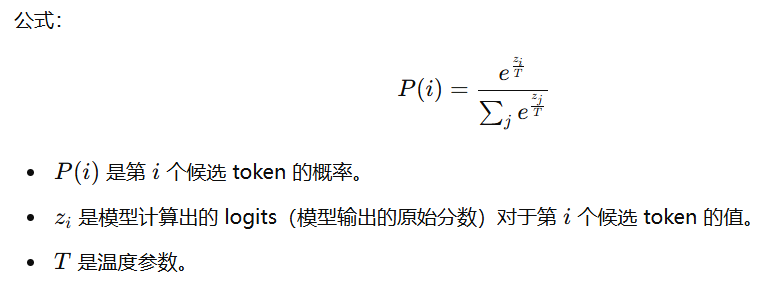
</div>


T数值越高，输出越随机多样；数值越低，输出越确定、保守，相同输入更容易得到相近的输出。

- 取值范围通常是 0~2
- 默认值通常为 1.0 ，此时不对模型输出的 Logits 进行额外缩放，按照模型原始概率分布进行采样
- 通常代码类任务设为0-0.2，创意写作类任务可大于1 

预期效果：
| temperature | 表现 |
|---|---|
| 0.0 | 多次运行结果更相近，措辞保守、平实 |
| 0.7 | 略有变化，但整体风格稳定 |
| 1.5 | 用词更跳跃、更有想象力，但也更容易出现不通顺或跑题的情况 |

**对比示例（同样的 prompt，不同 temperature）：**

In [56]:
import requests, json

headers={
    'Content-Type': 'application/json',
    'Authorization': f'Bearer {api_key}'
}

def ask(prompt, temperature):
    payload = json.dumps({
        "model": "deepseek-v4-flash",
        "messages": [{"role": "user", "content": prompt}],
        "temperature": temperature,
        "seed":5,  #为了减少其他参数的影响，这里固定seed随机数
        "thinking":{"type": "disabled"} #同时禁用深度思考
    })
    response = requests.post(url, headers=headers, data=payload)
    return response.json()['choices'][0]['message']['content']

prompt = "用一句话形容秋天"

for temp in [0.0, 0.7, 1.5]:
    print(f"--- temperature={temp} ---")
    print('1:',ask(prompt, temp))
    print('2:',ask(prompt, temp))
    print()

--- temperature=0.0 ---
1: 秋天是打翻的调色盘，风一吹，满世界都是金红橙黄的叹息。
2: 秋天是打翻的调色盘，风一吹，满世界都是金红橙黄的叹息。

--- temperature=0.7 ---
1: 秋风拂过，落叶轻旋，仿佛时光在低语，将夏日的热烈沉淀为一份温润的宁静与丰盈。
2: 秋天是天空被调高饱和度的季节，风把云絮纺成金线，缝补着大地褪色的衣衫。

--- temperature=1.5 ---
1: 秋风把夏天烤焦的蝉声，一片片剥成金黄的落叶，撒在我归家的路上。
2: 秋天的黄昏被风碾成碎金，从槐树尖儿一直铺到你眼底，那是一种连叹息都染上橘色的安静——既不悲伤，也不欢喜，只是天地间刚好薄得透光的一个转身。



#### 2. `top_p`（核采样 / nucleus sampling）

核采样是另一种控制随机性的方式，其思路是：模型在生成每个词时，会先把所有候选词按概率从高到低排序，**只在累计概率达到 `top_p` 的这部分候选词里**进行采样，忽略概率太低的"长尾"候选词。

- 取值范围 0~1
- `top_p=1.0` 表示不限制，所有候选词都参与采样，默认通常就是1
- `top_p` 越小，候选词范围越窄，输出越保守

**与 `temperature` 的关系：** 两者都是控制随机性的手段，**通常不建议同时使用**，一般传参只调另一个。

In [58]:
def ask(prompt, top_p):
    payload = json.dumps({
        "model": "deepseek-v4-flash",
        "messages": [{"role": "user", "content": prompt}],
        "top_p": top_p,
        "seed":5,  #为了减少其他参数的影响，这里固定seed随机数
        "thinking":{"type": "disabled"} #同时禁用深度思考
    })
    response = requests.post(url, headers=headers, data=payload)
    return response.json()['choices'][0]['message']['content']

prompt = "用一句话形容秋天"

for top_p in [0.001, 1]:
    print(f"--- top_p={top_p} ---")
    print('1:',ask(prompt, top_p))
    print('2:',ask(prompt, top_p))
    print()

--- top_p=0.001 ---
1: 秋天是打翻的调色盘，风一吹，满世界都是金红橙黄的叹息。
2: 秋天是打翻的调色盘，风一吹，满世界都是金红橙黄的叹息。

--- top_p=1 ---
1: 秋水共长天，落叶与斜阳共舞，万物在澄澈与凋零间静默成诗。
2: 秋天是被打翻的调色盘，每一片落叶都蘸着夕阳的余温，在风的笔触里，写下一年中最温柔的告别。



除了temperature、top_p外，模型内部的seed随机数等因素(不一定暴露给用户)也会影响随机性

### 控制回答的长度

#### 3. `max_tokens`（最大生成长度）
限制本次回复**最多生成多少个 token**。一旦达到这个上限，生成会被强制截断，即使内容还没说完。
- 此时response中的`finish_reason` 值将为 `"length"`。
- 正常结束时为`"stop"`

In [53]:
payload = json.dumps({
    "model": "deepseek-v4-flash",
    "messages": [{"role": "user", "content": "详细介绍一下人工智能的发展历史"}],
    "thinking":{"type": "enabled"},
    "max_tokens": 300  # 故意设置得很小，观察截断效果
})

response = requests.post(url, headers=headers, data=payload)
result = response.json()['choices'][0]
print(result['message']['content'])
print("结束原因：", result['finish_reason'])  # 注意观察这里

人工智能（AI）的发展史是一部充满雄心壮志、严冬低谷、技术突破与产业变革的史诗。它大致经历了以下几个标志性的阶段。

### 第一阶段
结束原因： length


### 控制深度思考

#### 4. `thinking`（是否启用思考模式）
是否启用深度思考，该参数在不同平台的具体字段名和取值可能不同，使用前建议查阅你正在用的那个平台的最新官方文档。

背后的具体方式根据平台也有所不同，可能是限制思考深度+隐藏思考过程，也可能是切换模型。


In [67]:
#开启深度思考
payload = json.dumps({
        "model": "deepseek-v4-flash",  #对于具备深度思考能力的模型，默认开启深度思考
        "messages": [{"role": "user", "content": "1+1=?"}],
    })
response=requests.post(url,headers=headers,data=payload)
reasoning_content=response.json()['choices'][0]['message']['reasoning_content']
content=response.json()['choices'][0]['message']['content']
print(f'【深度思考】:{reasoning_content}')
print(f'【正文】:{content}')
response.json()  #有reasoning_content字段

【深度思考】:We are asked: "1+1=?" This is a simple arithmetic question. The answer is 2. So I'll respond with that.
【正文】:1+1=2


{'id': 'as-p3ih96bmpn',
 'object': 'chat.completion',
 'created': 1782358217,
 'model': 'deepseek-v4-flash',
 'choices': [{'index': 0,
   'message': {'role': 'assistant',
    'content': '1+1=2',
    'reasoning_content': 'We are asked: "1+1=?" This is a simple arithmetic question. The answer is 2. So I\'ll respond with that.'},
   'finish_reason': 'stop',
   'flag': 0}],
 'usage': {'prompt_tokens': 8,
  'completion_tokens': 37,
  'total_tokens': 45,
  'completion_tokens_details': {'reasoning_tokens': 30}}}

In [69]:
#关闭深度思考
payload = json.dumps({
        "model": "deepseek-v4-flash",
        "messages": [{"role": "user", "content": "1+1=?"}],
        "thinking":{"type": "disabled"}  #关闭深度思考
    })
response=requests.post(url,headers=headers,data=payload)
content=response.json()['choices'][0]['message']['content']
print(f'【正文】:{content}')
response.json()  #无reasoning_content字段

【正文】:1+1=2


{'id': 'as-prm54c1qqe',
 'object': 'chat.completion',
 'created': 1782358249,
 'model': 'deepseek-v4-flash',
 'choices': [{'index': 0,
   'message': {'role': 'assistant', 'content': '1+1=2'},
   'finish_reason': 'stop',
   'flag': 0}],
 'usage': {'prompt_tokens': 8, 'completion_tokens': 6, 'total_tokens': 14}}

#### 5. `reasoning_effort`（推理强度）
控制推理强度，通常支持[low,medium,high,max]四档，具体请查阅使用平台的官网文档。

In [71]:
#deepseekv4只支持high和max，low与medium将自动映射至high
#示例 reasoning_effort=high
payload = json.dumps({
        "model": "deepseek-v4-flash",  #对于具备深度思考能力的模型，默认开启深度思考
        "messages": [{"role": "user", "content": "1+1=?"}],
        "reasoning_effort":"high" 
    })
response=requests.post(url,headers=headers,data=payload)
reasoning_content=response.json()['choices'][0]['message']['reasoning_content']
content=response.json()['choices'][0]['message']['content']
print(f'【深度思考】:{reasoning_content}')
print(f'【正文】:{content}')

【深度思考】:We are asked: "1+1=?" This is a simple arithmetic question. The answer is 2. So I will respond accordingly.
【正文】:1+1=2


In [72]:
#示例 reasoning_effort=max，深度思考将明显变长，通常在处理需要多步推理的复杂任务时取max
payload = json.dumps({
        "model": "deepseek-v4-flash",  #对于具备深度思考能力的模型，默认开启深度思考
        "messages": [{"role": "user", "content": "1+1=?"}],
        "reasoning_effort":"max"  
    })
response=requests.post(url,headers=headers,data=payload)
reasoning_content=response.json()['choices'][0]['message']['reasoning_content']
content=response.json()['choices'][0]['message']['content']
print(f'【深度思考】:{reasoning_content}')
print(f'【正文】:{content}')

【深度思考】:We need to answer the user's question: "1+1=?" This is a simple arithmetic question. The answer is 2. However, the user might be expecting a specific format or a detailed explanation. Since the instruction is just to respond with the answer, I'll provide the answer. But the model should be helpful and concise. So I'll say "2" or "1+1=2". Given that it's a straightforward question, I'll answer it directly.
【正文】:2


### 重复惩罚

#### 6.`presence_penalty` 与 `frequency_penalty`
**在复用之前已经出现过的词**时进行惩罚，取值范围通常是 -2.0 到 2.0。

- `frequency_penalty`：正值根据新token在文本中的出现频率进行惩罚，从而降低输出重复token的概率
- `presence_penalty`：正值根据新token到是否在文本中出现过进行惩罚，从而降低输出重复token的概率

**适用场景：** 长文本生成时，特别是创意写作场景时，会出现词、句或者是特定表达形式的反复重复，适当调高这两个参数可以缓解。

**注意：** 这两个参数已被多个平台废弃使用，建议使用temperature、top_p和prompt来避免重复。

## 1.8 工具调用

`工具调用(function call)`是对大模型能力的重要拓展。

大模型本身只会"生成文本"，它不能联网查实时天气、不能读取本地文件、也不能调用其他系统的接口。**工具调用就是让大模型调用开发者写好的函数，间接获得这些能力**。

> **关键认知：大模型本身不会执行任何函数。** 整个过程是：开发者预先定义好"有哪些函数可用、每个函数需要什么参数"，在发送请求时告诉大模型；大模型根据用户的问题，判断"需要调用哪个函数、传什么参数"，并以 JSON 格式输出这个调用意图；**真正执行这个函数的，是开发者自己的代码**，不是大模型。大模型拿到执行结果后，再继续生成最终的自然语言回答。

**概念区分**:
| 术语 | 含义 |
|---|---|
| **Function（函数）** | 开发者用编程语言（如 Python）实际写好的一个具体函数，比如 `get_weather(city)` |
| **Tool（工具）** | 描述这个函数的一份"说明书"，用标准 JSON Schema 格式告诉模型：这个工具叫什么名字、做什么用、需要传哪些参数、参数类型是什么 |
| **Function Call （函数调用）** | 模型分析完用户问题后，决定"我要调用某个工具，参数是这些"，并把这个决定以结构化 JSON 形式输出（注意：这只是模型"说"它要调用，不是真的在执行） |

**完整流程图**:
> 右侧分支可能循环多次——比如模型可能需要先调用"根据城市名获取城市id"，再根据城市id调用"查询天气"，两次工具调用之后才给出最终答案。
```mermaid
%%{init: {'theme': 'neutral', 'themeVariables': {'fontSize': '12px'}, 'flowchart': {'nodeSpacing': 15, 'rankSpacing': 20}}}%%
flowchart TD
    A[用户提问] --> B[开发者将 用户问题 + messages历史 + tools定义 一起发给模型]
    B --> C{模型判断：这个问题需要调用工具吗？}
    C -->|不需要| D[直接生成自然语言回答流程结束]
    C -->|需要| E[模型返回特殊响应：不含 content，而是含 tool_calls]
    E --> F[开发者解析 tool_calls拿到函数名和参数]
    F --> G[开发者在自己的代码里真正执行这个函数，得到结果]
    G --> H[开发者将函数执行结果作为新消息 role=tool 追加进 messages]
    H --> I[将更新后的完整 messages再发给模型]
    I --> J[模型基于工具执行结果生成最终的自然语言回答]
```

#### 工具调用全流程范例
现在我们按照函数定义、工具定义、对话传参、解析tool_call并执行函数、再次对话的顺序进行示例

**情景**:假设我们需要大模型进行可靠的数学运算，在遇到数学计算问题时提取用户prompt中的数学公式，并调用计算工具得到结果。

In [31]:
#定义函数
def calculate(expression:str)->str:
    """
    计算数学表达式的值
    :param expression: 数学表达式字符串，例如 "3 + 5 * 2"
    :return: 计算结果（字符串形式）
    """
    try:
        # 仅允许数字、运算符、括号、小数点等安全字符，防止任意代码执行
        allowed_chars = set("0123456789+-*/(). %")
        if not all(c in allowed_chars for c in expression):
            return f"错误：表达式包含不支持的字符 -> {expression}"
        
        result = eval(expression)
        return str(result)
    except Exception as e:
        return f"计算出错：{e}"
calculate("489879+8979845") #测试

'9469724'

In [32]:
#工具定义
#建议对照deepseek官网api文档：https://api-docs.deepseek.com/api/create-chat-completion
#https://api-docs.deepseek.com/guides/tool_calls
#tools参数是一个list，其中一个tool对应一个字典对象
tools=[   
    {
        "type": "function",
        "function": {
            "name": "calculate",  #函数名
            #description给出函数功能的描述，大模型根据description决定何时调用以及如何调用该函数
            "description": "当用户的问题中包含具体的数学算式或计算需求时，提取出数学表达式并调用本工具计算结果。例如用户说'帮我算一下3加5乘2'，应提取为'3+5*2'后调用。",  
            #parameters是一个json schema对象(后续将做进一步介绍)，用于校验函数入参是否正确。函数无入参时不用定义parameters
            "parameters": {
                "type": "object",
                "properties": { 
                    "expression": {   #一个参数一条
                        "type": "string",
                        "description": "从用户提问中提取出的标准数学表达式，只能包含数字和 + - * / ( ) % 等运算符，例如 '(12+8)/4'"
                    }
                },
                "required": ["expression"] #必须的参数
            }
        }
    }
]
# 维护一份函数名到真实函数的映射，现在我们可以通过字符串形式的函数名调用到对应函数了
available_functions = {
    "calculate": calculate
}
available_functions["calculate"]("489879+8979845")

'9469724'

In [33]:
#第一轮对话
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.environ.get("QIANFAN_API_KEY")

import requests
import json
import os
url = "https://qianfan.baidubce.com/v2/chat/completions"
headers = {
    'Content-Type': 'application/json',
    'Authorization': f'Bearer {api_key}'
}

messages=[{"role":"user","content":"帮我算一下 489879+8979845 等于多少？"}] #用户询问数学计算相关的问题

payload={
    "model":"deepseek-v4-flash",
    "messages":messages,
    "tools":tools
}
response=requests.post(url,headers=headers,json=payload)
response.json() #注意，此时响应中出现了tool_calls字段，现在我们需要解析tool_calls，调用对应的函数

{'id': 'as-iu7fysv2sk',
 'object': 'chat.completion',
 'created': 1782459557,
 'model': 'deepseek-v4-flash',
 'choices': [{'index': 0,
   'message': {'role': 'assistant',
    'content': '\n',
    'reasoning_content': '用户想让我计算 489879 + 8979845 的结果。这是一个简单的加法运算，我直接计算。',
    'tool_calls': [{'id': 'call_2ee4fae185a04f3e88438b42',
      'type': 'function',
      'index': 0,
      'function': {'name': 'calculate',
       'arguments': '{"expression": "489879+8979845"}'}}]},
   'finish_reason': 'tool_calls',
   'flag': 0}],
 'usage': {'prompt_tokens': 371,
  'completion_tokens': 73,
  'total_tokens': 444,
  'completion_tokens_details': {'reasoning_tokens': 24}}}

In [34]:
#解析tool_calls，调用对应的函数
assistant_message = response.json()["choices"][0]["message"]
messages.append(assistant_message) #管理messages,tool_calls本身也要作为上下文加入messages
#尝试获取tool_calls
tool_calls = assistant_message.get("tool_calls")
if tool_calls: 
    for tool_call in tool_calls: #注意，模型可能同时调用多个工具
        func_name = tool_call["function"]["name"]          # 函数名，例如 "calculate"
        func_args_str = tool_call["function"]["arguments"]  # 参数是字符串形式的JSON
        func_args = json.loads(func_args_str)               # 解析成字典

        # 通过映射找到真正的函数并执行
        func = available_functions.get(func_name)

        if func:
            func_result = func(**func_args)  # 等价于 calculate(expression=...)，**将字典解包为关键字参数
        else:
            func_result = f"错误：未找到名为 {func_name} 的工具"
            
        print(f"调用工具 {func_name}，参数 {func_args}，结果：{func_result}")

        # 将工具执行结果作为一条 role=tool 的消息加入对话历史
        messages.append({
            "role": "tool",
            "tool_call_id": tool_call["id"],  # 必须对应上面tool_call的id
            "content": func_result
        })

调用工具 calculate，参数 {'expression': '489879+8979845'}，结果：9469724


In [35]:
#第二轮对话
payload2 = {
    "model": "deepseek-v4-flash",
    "messages": messages,
    "tools": tools  # 一般继续带上tools，保持上下文一致
}
response2 = requests.post(url, headers=headers, json=payload2)
response2_data = response2.json()

final_answer = response2_data["choices"][0]["message"]["content"]
print("\n最终回答：")
print(final_answer)


最终回答：
计算结果为 **9,469,724**。


**注意**：在你使用各平台和大模型对话的时候，你并不会看到第一轮对话到第二轮对话结果之间的过程，调用工具的过程由后台自动实现，用户只会看到大模型的最终答复。
同时，我们在第二轮对话时没有检查大模型的回复是否包含tool_calls，在实际应用中，我们会通过循环进行反复确认，直到不需要调用工具才会将最终答复交给用户。

后续我们将通过另外的教程更详细的介绍如何在本地实现一个包含function call和messages上下文管理的框架。

#### JSON Schema